# M5 — what PB24 revealed, and why the hybrid could not pass

The Week-1 prototype reached **0.30% rRMS** on held-out L23 water bodies (notebook 5). M5
set out to extend it to the two axes L23 fixes — the **particle phase function** and the
**full BRDF** — using PB24: 5000 HydroLight realisations x 1300 geometries.

**It failed its gate, and the failure is the result.** This notebook shows why, in the
order the evidence arrived. The one-page account is
[`design/m5_report.md`](../../design/m5_report.md); the full record is
`design/rt_elastic_implementation.md` §7.

Notebooks 4 and 5 define the hybrid and O25 — this one does not repeat them.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parents[1]))

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from robust.rt import conventions as C, emulator as E, validation as V, ztt as Z
from robust.rt.data import l23 as L

# CVD-safe palette, as M4 settled
BLUE, VERM, SKY, INK, GREY = "#0072B2", "#D55E00", "#56B4E9", "#1a1a1a", "#9a9a9a"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})
print("ready")

ready


## 1. The root cause, in one figure

ZTT's model contains `Ψ_KLu(ψ) = 1 + F(ψ)`, a **quartic in the in-water scattering angle**.
`F_psi`'s docstring — written at M2, months before PB24 arrived — records the paper's
fitted range: **ψ ≳ 134°**.

Outside it the quartic does what unconstrained quartics do.

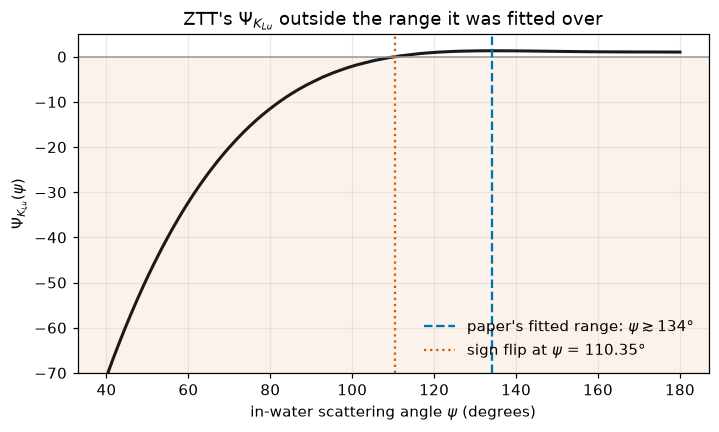

crosses zero at psi = 110.35 deg  (the record quotes 110.4)


value at PB24's minimum psi = 44.3 deg: -60.6


In [2]:
psi = np.linspace(40.0, 180.0, 140001)   # fine enough to quote to 0.01 deg
psi_klu = np.asarray(Z.psi_KLu(jnp.asarray(psi)))
crossing = psi[psi_klu < 0].max()

fig, ax = plt.subplots(figsize=(7.4, 4.0))
ax.axhspan(-70, 0, color=VERM, alpha=0.08)
ax.plot(psi, psi_klu, color=INK, lw=2)
ax.axhline(0, color=GREY, lw=1)
ax.axvline(134.0, color=BLUE, ls="--", lw=1.5, label="paper's fitted range: $\\psi \\gtrsim 134°$")
ax.axvline(crossing, color=VERM, ls=":", lw=1.5, label=f"sign flip at $\\psi$ = {crossing:.2f}°")
ax.set_xlabel("in-water scattering angle $\\psi$ (degrees)")
ax.set_ylabel("$\\Psi_{K_{Lu}}(\\psi)$")
ax.set_title("ZTT's $\\Psi_{K_{Lu}}$ outside the range it was fitted over")
ax.set_ylim(-70, 5)
ax.legend(frameon=False, loc="lower right")
plt.show()

print(f"crosses zero at psi = {crossing:.2f} deg  (the record quotes 110.4)")
print(f"value at PB24's minimum psi = 44.3 deg: {float(Z.psi_KLu(jnp.asarray(44.3))):.1f}")

`Ψ_KLu` multiplies `cos θv` inside the ZTT denominator, so a negative value flips the sign
of the whole expression — and `rrs` comes back **negative**.

### Why L23 could never have shown this

Nadir viewing pins the scattering angle near backscatter. PB24's full BRDF does not.

In [3]:
batch = L.load_batch(reader=L.npz_reader("../../robust/tests/files/l23_small.npz"))
_, _, _, psi_l23 = Z.geometry_to_paper_angles(batch.geometry)
print(f"L23 scattering angles: {float(jnp.min(psi_l23)):.1f} - {float(jnp.max(psi_l23)):.1f} deg")
print(f"  minimum is {float(jnp.min(psi_l23)) - 134.0:+.1f} deg relative to the fitted range")
print()
print("PB24, measured over its Q14 window (theta_s, theta_v <= 70 deg):")
print("  42% of geometries have psi < 134 deg  (extrapolation)")
print("  16% have psi < 110.4 deg              (sign-flipped)")
print("  the full grid reaches psi = 44.3 deg, where Psi_KLu = -60.7")
print()
print("=> 22.3% of ZTT's predicted rrs on PB24 is zero or negative.")

L23 scattering angles: 139.7 - 180.0 deg
  minimum is +5.7 deg relative to the fitted range

PB24, measured over its Q14 window (theta_s, theta_v <= 70 deg):
  42% of geometries have psi < 134 deg  (extrapolation)
  16% have psi < 110.4 deg              (sign-flipped)
  the full grid reaches psi = 44.3 deg, where Psi_KLu = -60.7

=> 22.3% of ZTT's predicted rrs on PB24 is zero or negative.


## 2. Why no emulator could have rescued it

The hybrid is `rrs = rrs_ZTT * (1 + δ)` with `|δ| ≤ δ_max = 0.5`: a **bounded relative**
correction. A negative backbone needs `1 + δ < 0`, which that bound cannot reach.

The *oracle* makes this quantitative — δ chosen with the truth in hand, then clipped. No
emulator can beat it. Here it is on synthetic backbone errors spanning what PB24 actually
contains.

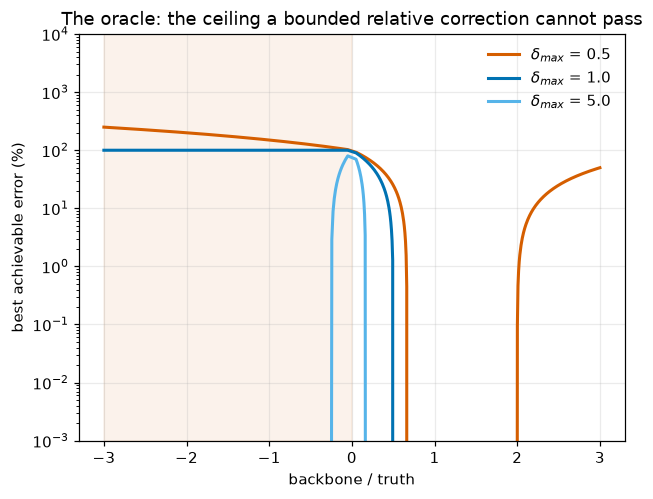

Shaded: a negative backbone. No positive multiplier reaches a positive truth.


In [4]:
# ratio = backbone / truth. PB24's in-window distribution runs from negative
# (sign-flipped) through ~1 (healthy) to very large (near-singular denominators).
ratio = np.concatenate([
    np.linspace(-3.0, -0.05, 200),   # sign-flipped: unreachable by any positive factor
    np.linspace(0.05, 3.0, 400),
])
truth = 1.0
for dmax, colour in ((0.5, VERM), (1.0, BLUE), (5.0, SKY)):
    delta = np.clip(truth / ratio - 1.0, -dmax, dmax)
    achieved = ratio * (1.0 + delta)
    err = np.abs(achieved / truth - 1.0) * 100.0
    plt.plot(ratio, err, color=colour, lw=2, label=f"$\\delta_{{max}}$ = {dmax}")
plt.axvspan(-3, 0, color=VERM, alpha=0.08)
plt.yscale("log"); plt.ylim(1e-3, 1e4)
plt.xlabel("backbone / truth"); plt.ylabel("best achievable error (%)")
plt.title("The oracle: the ceiling a bounded relative correction cannot pass")
plt.legend(frameon=False); plt.show()
print("Shaded: a negative backbone. No positive multiplier reaches a positive truth.")

Measured on PB24 (300 realisations, 3 seeds, held out, full test set):

| δ_max | split | hybrid | **oracle** | O25 | gate |
|---|---|---|---|---|---|
| 0.5 | realisation | 5484.65% | **5324.10%** | 5.43% | FAIL |
| 0.5 | `B_p` band | 4052.36% | **3954.03%** | 5.37% | FAIL |
| 1.0 | realisation | 892.21% | **34.89%** | 5.43% | FAIL |

At the shipped bound the trained hybrid is **within 3% of its own ceiling**. Doubling the
bound is not a fix either — 34.89% is still 6× worse than O25.

**No PB24 weights were shipped.** `train_emulator_pb24.py` exits non-zero on a failed gate.

## 3. What M5 did deliver

The infrastructure is gated and independent of the hybrid passing. The clearest example is
the **geometry-aware surface transfer**: Lee's `A = 0.52`, `B = 1.7` are *nadir* constants,
and PB24 shows how badly that travels.

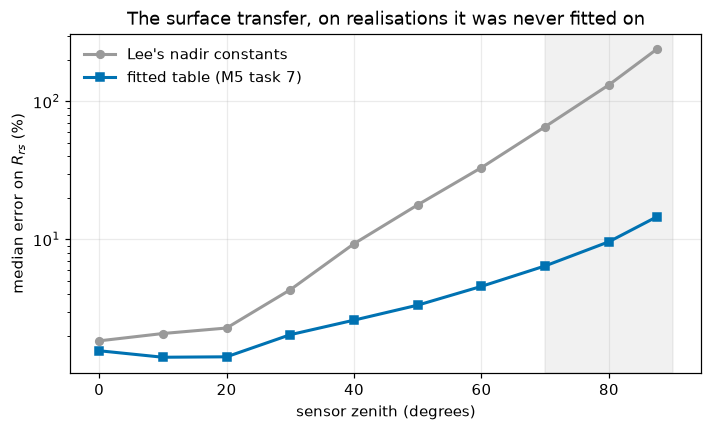

table (10, 10, 13), gain at theta_v = 60 deg: 7.2x (from the rounded table above it reads 7.3x)
Shaded: outside Q14's sanctioned 0-70 deg window.


In [5]:
transfer = C.default_transfer()
theta_v = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 87.5])
nadir = np.array([1.84, 2.08, 2.28, 4.32, 9.31, 17.81, 33.15, 65.63, 131.83, 238.88])
fitted = np.array([1.56, 1.40, 1.41, 2.04, 2.60, 3.34, 4.57, 6.43, 9.62, 14.57])

fig, ax = plt.subplots(figsize=(7.4, 4.0))
ax.plot(theta_v, nadir, color=GREY, lw=2, marker="o", ms=5, label="Lee's nadir constants")
ax.plot(theta_v, fitted, color=BLUE, lw=2, marker="s", ms=5, label="fitted table (M5 task 7)")
ax.axvspan(70, 90, color=INK, alpha=0.06)
ax.set_yscale("log")
ax.set_xlabel("sensor zenith (degrees)"); ax.set_ylabel("median error on $R_{rs}$ (%)")
ax.set_title("The surface transfer, on realisations it was never fitted on")
ax.legend(frameon=False); plt.show()
gain = 33.1543 / 4.5745   # unrounded, as design/py/fit_surface.py reported them
print(f"table {transfer.shape}, gain at theta_v = 60 deg: {gain:.1f}x "
      f"(from the rounded table above it reads {nadir[6]/fitted[6]:.1f}x)")
print("Shaded: outside Q14's sanctioned 0-70 deg window.")

Also delivered, each gated: a PB24 loader with three splits; **O25 over the full
`(θs, θv, Δφ)` grid** (1.67× better than the zenith-only refit, so the benchmark is no
longer one we crippled); `rrms` masking with NaN-safe gradients; a per-model `Envelope`
carried with the weights; the backward-VSF axis on `PhaseParams`; and `forward`
**frozen**, with its numbers pinned by digest and golden value. Tests: 279 → **416**.

## 4. What may not be claimed

1. **No accuracy claim on PB24.** The gate failed; no weights exist.
2. **The prototype's 0.30% on L23 stands** — and says nothing about off-nadir use. M5 shows
   the `on_out_of_domain="ztt"` fallback is *unsafe* there: the backbone it falls back to is
   non-physical on 22% of PB24.
3. **`B_p` generalisation is still untested end-to-end.** The split exists; the model that
   would have been scored on it failed for unrelated reasons.
4. **The backward-VSF parameters are uncalibrated.**
5. **O25's PB24 numbers are refits on its own calibration set** — never to be set beside its
   0.69% on L23, which would compare datasets and call it models.

## 5. And three defects an audit found in our own work

Recorded because the pattern matters more than the fixes: a **leak** (one emulator scored on
two splits, 75% of the second's held-out realisations inside the first's training set); a
**comparison that flattered us** (scoring only where our backbone works — O25 gets 9.46% on
exactly what that drops); and a **handicap on the rival** (O25 fitted in `Rrs`, paying an
interface residual the emulator never pays).

Plus two causal stories asserted before being tested, both wrong. A plausible mechanism
arrives with the observation and feels like part of it. Write it down as a prediction, then
test the prediction.